Import Plugin

In [ ]:
import nltk
import string

import pandas as pd
import matplotlib.pyplot as plt
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.tokenize import sent_tokenize

nltk.download('stopwords')
nltk.download('punkt_tab')
nltk.download('punkt')

from sklearn.feature_extraction.text import TfidfVectorizer

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Bara\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Bara\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Bara\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [ ]:
paragraph_manchester = """
Manchester City makes history by winning Club World Cup

Manchester City capped off its incredible year with yet another trophy, dismantling Fluminense 4-0 to win the Club World Cup on Friday.

Having already won the Premier League, Champions League, FA Cup and Super Cup, Pep Guardiola's side now boasts five trophies this calendar year, becoming the first English club to ever hold all those titles simultaneously.

The final piece of the jigsaw came on a highly charged night in Saudi Arabia as Manchester City outclassed its Brazilian opponents.

"We've shown over the past 12 months we are the best team in the world. Our results prove that and the consistency we have managed has been amazing," club captain Kyle Walker said after the game, per Sky Sports.

"To win these five trophies - for me, the five biggest prizes available to us - is incredible. I am so proud to have been a part of this and I can honestly say it's an honour to play alongside these players. I couldn't ask for better teammates."

It took just 40 seconds for Manchester City to take the lead.

Brazilian left-back Marcelo miscued a pass in the opening exchanges which let Nathan Ake free to shoot from distance. The defender's effort cannoned back off the post but forward Julian Alvarez was in the right place to turn the rebound into the net with his chest.

City continued to look dangerous and doubled its lead before the break after Phil Foden's attempted cross was deflected into his own net by Fluminense defender Nino.

Foden then got on the scoresheet himself in the 72nd minute after a prodding home from close range.

The rout was completed in the 88th minute when Alvarez capped off a brilliant performance with a clinical finish into the far corner.

City's defence was largely untested for during the game, underlining the team's dominance during this unforgettable year.

"As a manager it is what I am most proud of; that we are always there. No matter how much we win, no matter what trophies we lift, we are there again to fight for the next one," City boss Guardiola said after the match, according to Sky Sports.

"To win the Treble was truly special, but to win two more trophies and now hold these five major titles shows the unique mentality of this team, of the Club and its fans.

"It is something no other English team has ever achieved, and we will always remember this incredible time we spent together."

The game ended in some unsavoury scenes as a scuffle broke out between players on the pitch after the final whistle, but the game will be remembered as yet another successful night for City.

The champion heads back to England where it faces a tough title defence in the Premier League.

It currently sits fourth in the table and will face Everton in its next fixture on Wednesday.
"""

Preview text Manchester

In [ ]:
print(paragraph_manchester)


Manchester City makes history by winning Club World Cup

Manchester City capped off its incredible year with yet another trophy, dismantling Fluminense 4-0 to win the Club World Cup on Friday.

Having already won the Premier League, Champions League, FA Cup and Super Cup, Pep Guardiola’s side now boasts five trophies this calendar year, becoming the first English club to ever hold all those titles simultaneously.

The final piece of the jigsaw came on a highly charged night in Saudi Arabia as Manchester City outclassed its Brazilian opponents.

“We’ve shown over the past 12 months we are the best team in the world. Our results prove that and the consistency we have managed has been amazing,” club captain Kyle Walker said after the game, per Sky Sports.

“To win these five trophies – for me, the five biggest prizes available to us – is incredible. I am so proud to have been a part of this and I can honestly say it’s an honour to play alongside these players. I couldn’t ask for better t

Data Clean

In [ ]:
sentences_dirty = sent_tokenize(paragraph_manchester)
sentences = []

translator = str.maketrans('', '', string.punctuation)
stop_words = stopwords.words("english")

for i in range(len(sentences_dirty)):
    #lower
    current_sentence = sentences_dirty[i]
    current_sentence = current_sentence.lower()

    #remove punctuations
    current_sentence = current_sentence.replace('\n\n', ' ').translate(translator)
    current_sentence = current_sentence.replace('\n', ' ').strip()

    #remove stopwords
    sentence_cleaned = []
    sentence_tokens = word_tokenize(current_sentence)
    for token in sentence_tokens:
        if token not in stop_words:
            sentence_cleaned.append(token)

    current_sentence = " ".join(sentence_cleaned)

    sentences.append(current_sentence)

print(sentences)

['manchester city makes history winning club world cup manchester city capped incredible year yet another trophy dismantling fluminense 40 win club world cup friday', 'already premier league champions league fa cup super cup pep guardiola ’ side boasts five trophies calendar year becoming first english club ever hold titles simultaneously', 'final piece jigsaw came highly charged night saudi arabia manchester city outclassed brazilian opponents', '“ ’ shown past 12 months best team world', 'results prove consistency managed amazing ” club captain kyle walker said game per sky sports', '“ win five trophies – five biggest prizes available us – incredible', 'proud part honestly say ’ honour play alongside players', '’ ask better teammates ” took 40 seconds manchester city take lead', 'brazilian leftback marcelo miscued pass opening exchanges let nathan aké free shoot distance', 'defender ’ effort cannoned back post forward julián álvarez right place turn rebound net chest', 'city continue

TF-IDF

In [4]:
vectorizer = TfidfVectorizer()
features = vectorizer.fit_transform(sentences)

print(features.shape)

words = vectorizer.get_feature_names_out()
tfidf_df = pd.DataFrame(features.toarray(), columns=words)
tfidf_df

(20, 198)


,12,40,72nd,88th,according,achieved,aké,alongside,already,always,...,us,walker,wednesday,whistle,win,winning,world,year,yet,álvarez
0,0.00000,0.180051,0.000000,0.000000,0.00000,0.00000,0.000000,0.00000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.00000,0.148830,0.204832,0.360101,0.162468,0.180051,0.000000
1,0.00000,0.000000,0.000000,0.000000,0.00000,0.00000,0.000000,0.00000,0.203567,0.000000,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.161465,0.000000,0.000000
2,0.00000,0.000000,0.000000,0.000000,0.00000,0.00000,0.000000,0.00000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,0.39839,0.000000,0.000000,0.000000,0.00000,0.00000,0.000000,0.00000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.350191,0.000000,0.000000,0.000000
4,0.00000,0.000000,0.000000,0.000000,0.00000,0.00000,0.000000,0.00000,0.000000,0.000000,...,0.000000,0.283125,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
5,0.00000,0.000000,0.000000,0.000000,0.00000,0.00000,0.000000,0.00000,0.000000,0.000000,...,0.349183,0.000000,0.000000,0.00000,0.253714,0.000000,0.000000,0.000000,0.000000,0.000000
6,0.00000,0.000000,0.000000,0.000000,0.00000,0.00000,0.000000,0.36405,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
7,0.00000,0.301176,0.000000,0.000000,0.00000,0.00000,0.000000,0.00000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
8,0.00000,0.000000,0.000000,0.000000,0.00000,0.00000,0.279807,0.00000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
9,0.00000,0.000000,0.000000,0.000000,0.00000,0.00000,0.000000,0.00000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.242949


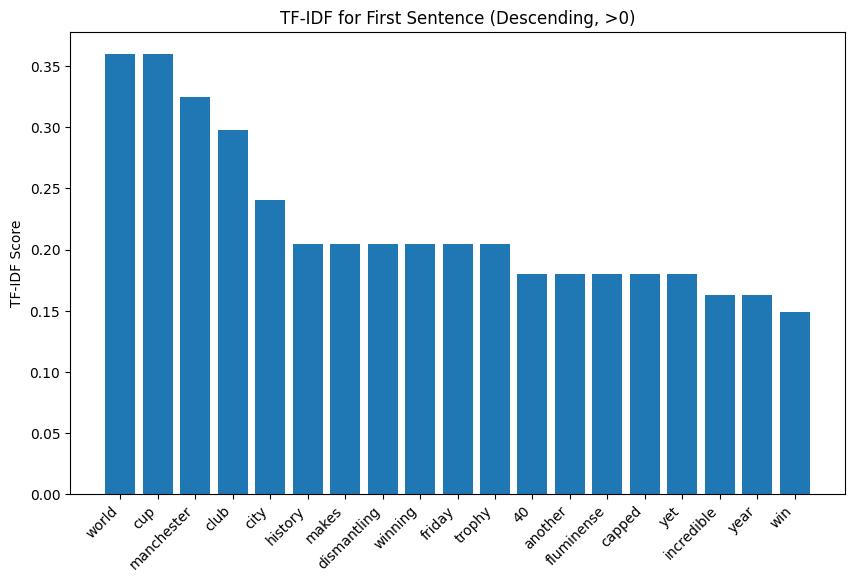

In [5]:
first_sentence_tfidf = tfidf_df.iloc[0]

first_sentence_tfidf = first_sentence_tfidf[first_sentence_tfidf > 0].sort_values(ascending=False)

# plot
plt.figure(figsize=(10, 6))
plt.bar(first_sentence_tfidf.index, first_sentence_tfidf.values)
plt.xticks(rotation=45, ha='right')
plt.ylabel("TF-IDF Score")
plt.title("TF-IDF for First Sentence (Descending, >0)")
plt.show()

Text Summarization

In [6]:
averages = []

for index, data in tfidf_df.iterrows():
    row_average = 0
    # get average of tf-idf for all words that appear in the sentence
    if (data != 0).sum() > 0:
        row_average = data.sum() / (data != 0).sum()

        averages.append(row_average)

overall_average = 0
if (len(averages) > 0):
    overall_average = sum(averages) / len(averages)

print(f"Minimum value: {overall_average}")
for i in range(0, len(averages)):
    print(f"Sentence {i + 1} value: {averages[i]}")

final_result = ""
final_result_neat = ""

sentences_in_summary = []
for i in range(len(averages)):
    if (averages[i] > overall_average):
        final_result +=  " " + sentences_dirty[i]
        final_result_neat += " " + sentences_dirty[i] + "\n"
        sentences_in_summary.append(i)

print("\nSentences in summary:")
print(sentences_in_summary)

Minimum value: 0.29817559571713576
Sentence 1 value: 0.22031665404388004
Sentence 2 value: 0.20205992698598974
Sentence 3 value: 0.2652015589517757
Sentence 4 value: 0.37594441273397283
Sentence 5 value: 0.2660732656101364
Sentence 6 value: 0.34188121751768485
Sentence 7 value: 0.35303861869140085
Sentence 8 value: 0.3130793169925133
Sentence 9 value: 0.27720336424783487
Sentence 10 value: 0.26683398987072904
Sentence 11 value: 0.24841611935072547
Sentence 12 value: 0.33288895222983694
Sentence 13 value: 0.288254825096976
Sentence 14 value: 0.31226553970114157
Sentence 15 value: 0.5762424963058678
Sentence 16 value: 0.2392076932593301
Sentence 17 value: 0.24610206605064505
Sentence 18 value: 0.18979967429325326
Sentence 19 value: 0.31561616766361633
Sentence 20 value: 0.33308605474540326

Sentences in summary:
[3, 5, 6, 7, 11, 13, 14, 18, 19]


In [ ]:
print("Word counts:")
print(f"Original text: {len(paragraph_manchester)}")
print(f"Summary: {len(final_result)}")

print("\nFinal summary: \n")
print(final_result)

Word counts:
Original text: 2796
Summary: 863

Final summary: 

 “We’ve shown over the past 12 months we are the best team in the world. “To win these five trophies – for me, the five biggest prizes available to us – is incredible. I am so proud to have been a part of this and I can honestly say it’s an honour to play alongside these players. I couldn’t ask for better teammates.”

It took just 40 seconds for Manchester City to take the lead. Foden then got on the scoresheet himself in the 72nd minute after a prodding home from close range. City’s defence was largely untested for during the game, underlining the team’s dominance during this unforgettable year. “As a manager it is what I am most proud of; that we are always there. The champion heads back to England where it faces a tough title defence in the Premier League. It currently sits fourth in the table and will face Everton in its next fixture on Wednesday.
